In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [84]:
nav = pd.read_csv("../data/processed/cleaned_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [85]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


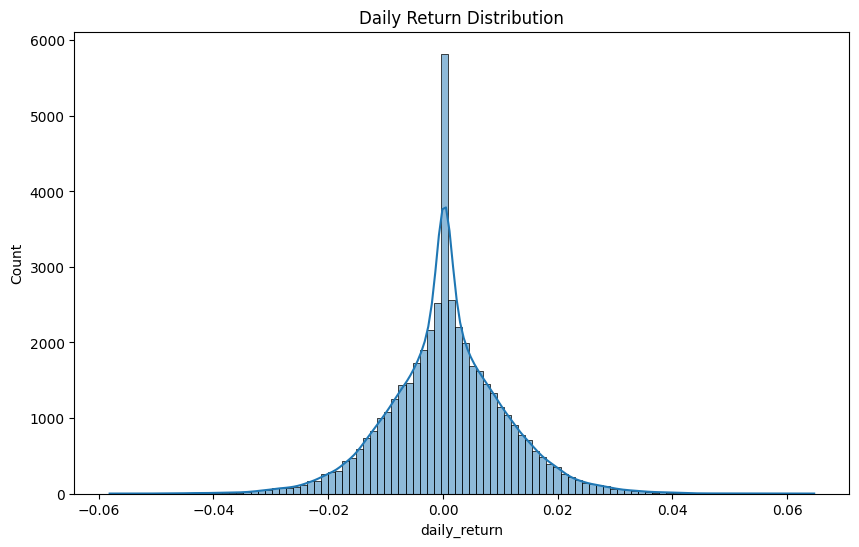

In [86]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

### Insight 1

Daily returns are centered around zero with occasional extreme movements, which is typical for mutual fund NAV behavior.

In [87]:
def calculate_cagr(df):

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] - df.iloc[0]["date"]).days
        / 365
    )

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )

    return cagr

In [88]:
cagr_results = []

for code, group in nav.groupby("amfi_code"):

    cagr = calculate_cagr(group)

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [89]:

risk_free_rate = 0.065
sortino_results = []

for code, group in nav.groupby("amfi_code"):

    mean_return = group["daily_return"].mean() * 252

    downside = group[
        group["daily_return"] < 0
    ]["daily_return"]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        (mean_return - risk_free_rate)
        / downside_std
    )

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [90]:
risk_free_rate = 0.065

sharpe_results = []

for code, group in nav.groupby("amfi_code"):

    mean_return = group["daily_return"].mean() * 252

    volatility = (
        group["daily_return"].std()
        * np.sqrt(252)
    )

    sharpe = (
        (mean_return - risk_free_rate)
        / volatility
    )

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


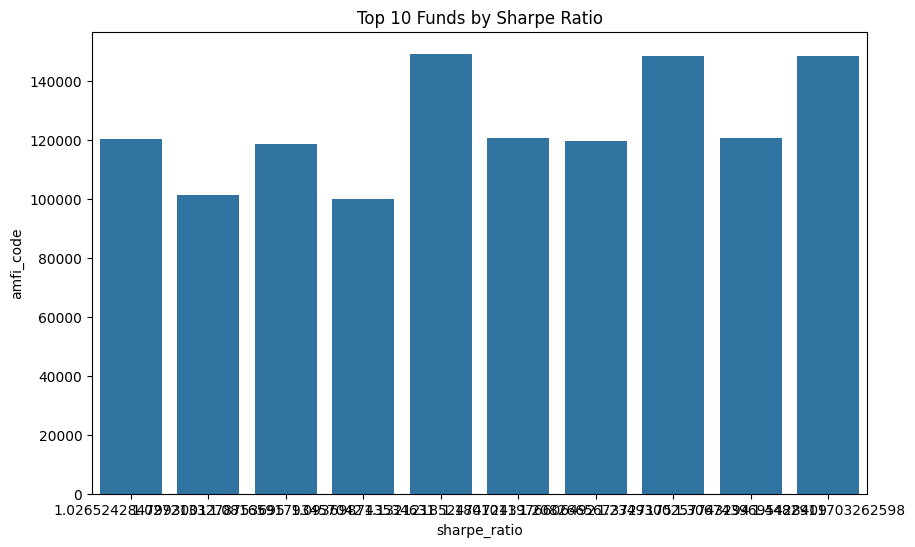

In [91]:
top_sharpe = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="amfi_code"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

In [92]:
sortino_results = []

for code, group in nav.groupby("amfi_code"):

    mean_return = group["daily_return"].mean() * 252

    downside = group[
        group["daily_return"] < 0
    ]["daily_return"]

    downside_std = downside.std() * np.sqrt(252)

    sortino = (
        (mean_return - risk_free_rate)
        / downside_std
    )

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [93]:
benchmark = (
    nav.groupby("date")["daily_return"]
       .mean()
       .reset_index()
)

alpha_beta_results = []

for code, group in nav.groupby("amfi_code"):

    merged = pd.merge(
        group,
        benchmark,
        on="date",
        suffixes=("_fund", "_benchmark")
    )

    merged = merged.dropna()

    slope, intercept, r, p, stderr = linregress(
        merged["daily_return_benchmark"],
        merged["daily_return_fund"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_results.append(
        [code, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


In [94]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [95]:
drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] / running_max
        - 1
    )

    max_dd = drawdown.min()

    drawdown_results.append(
        [code, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [96]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
)

scorecard["score"] = (
    scorecard["cagr"].rank(pct=True) * 30
    + scorecard["sharpe_ratio"].rank(pct=True) * 25
    + scorecard["alpha"].rank(pct=True) * 20
    + (-scorecard["max_drawdown"]).rank(pct=True) * 25
)

scorecard.sort_values(
    "score",
    ascending=False
).head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,score
25,120505,0.328016,1.180101,0.102647,1.194815,-0.181885,86.125
36,148569,0.319245,1.234930,0.096473,1.174586,-0.163967,81.125
2,100033,0.300997,1.093699,0.114423,0.991590,-0.162172,77.750
34,148567,0.309499,1.448291,0.181968,0.557134,-0.112657,77.000
19,119551,0.257849,1.208267,0.141513,0.562931,-0.150124,76.500


In [97]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


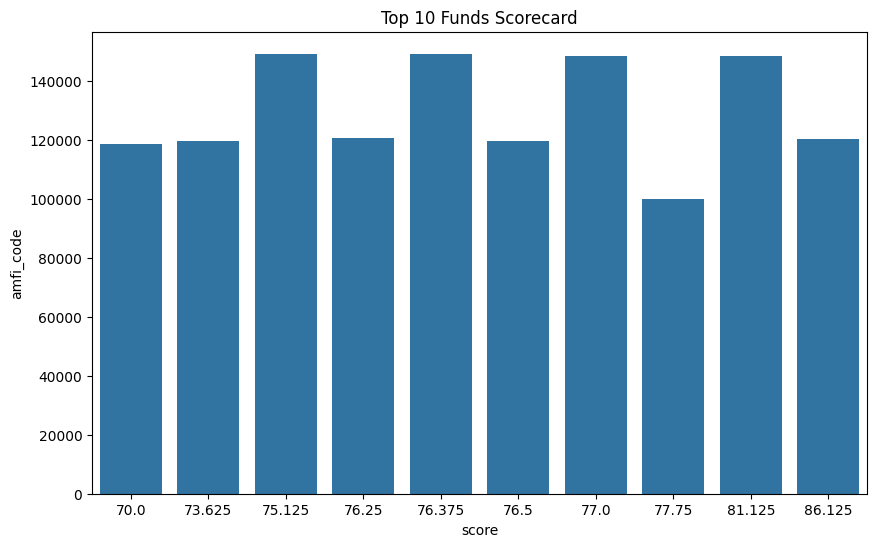

In [98]:
top10 = scorecard.sort_values(
    "score",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="score",
    y="amfi_code"
)

plt.title("Top 10 Funds Scorecard")

plt.show()

In [ ]:
top5_codes = scorecard.sort_values(
    "score",
    ascending=False
).head(5)["amfi_code"]

plt.figure(figsize=(12,6))

for code in top5_codes:
    fund_data = nav[nav["amfi_code"] == code]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(code)
    )

plt.title("Top 5 Funds Benchmark Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.show()